# Hotel Booking Cancellation — v2 · model comparison and reference model

Notebooks 04–09 scored six models on the same five saved outer folds. This notebook puts them side by
side, builds `reports/results/v2/leaderboard.csv`, and picks the reference model for stages 9.4–9.6
with the stop/go rule of plan §9.1. Only training-data results are read; `test.csv` stays closed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import average_precision_score

palette = ['#2B5C8F', '#E05A47']
results = Path('../../reports/results/v2')

## 1. Per-fold scores

In [2]:
# ordered from simplest / most auditable to least, which is also the order rule 9.1 is applied in
order = ['dummy', 'logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'neural_network']

per_fold = {}
for slug in order:
    df = pd.read_csv(results / f'{slug}.csv')
    per_fold[slug] = df[df.outer_fold.isin(list('01234'))].assign(outer_fold=lambda d: d.outer_fold.astype(int))

ap = pd.DataFrame({slug: df.set_index('outer_fold')['ap'] for slug, df in per_fold.items()})
ap.round(4)

,dummy,logistic_regression,decision_tree,random_forest,xgboost,neural_network
outer_fold,,,,,,
0,0.2775,0.6451,0.7098,0.7603,0.7726,0.7557
1,0.2775,0.6491,0.7144,0.7646,0.7727,0.7529
2,0.2775,0.6369,0.7049,0.7562,0.7608,0.7362
3,0.2775,0.6469,0.7083,0.7516,0.7612,0.7405
4,0.2775,0.6270,0.6959,0.7434,0.7547,0.7331


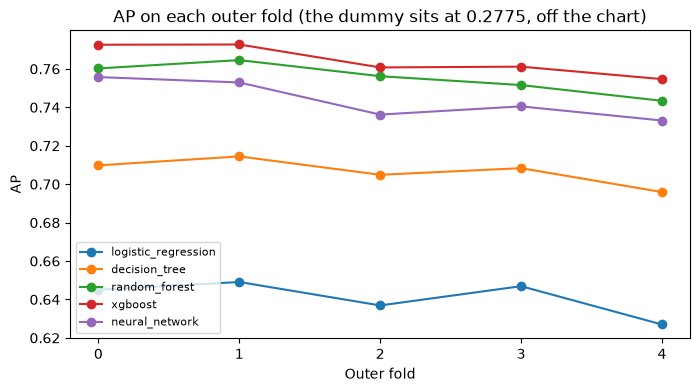

In [3]:
plt.figure(figsize=(8, 4))
for i, slug in enumerate(order[1:]):
    plt.plot(ap.index, ap[slug], marker='o', label=slug)
plt.xticks(ap.index)
plt.xlabel('Outer fold')
plt.ylabel('AP')
plt.title('AP on each outer fold (the dummy sits at 0.2775, off the chart)')
plt.legend(fontsize=8)
plt.show()

## 2. Leaderboard

In [4]:
rows = []
for rank, slug in enumerate(order):
    df = per_fold[slug]
    oof = pd.read_csv(results / 'oof' / f'{slug}.csv')
    assert len(oof) == 67974 and (oof.row_id.to_numpy() == np.arange(len(oof))).all()
    rows.append({
        'model': df['model'].iloc[0], 'slug': slug, 'complexity_rank': rank,
        'ap_mean': df['ap'].mean(), 'ap_sd': df['ap'].std(),
        **{f'ap_fold_{k}': v for k, v in df.set_index('outer_fold')['ap'].items()},
        'pooled_oof_ap': average_precision_score(oof.is_canceled, oof.proba),
        'precision': df['precision'].mean(), 'recall': df['recall'].mean(), 'f1': df['f1'].mean(),
        'search_seconds': df['search_seconds'].mean(), 'refit_seconds': df['refit_seconds'].mean(),
        'predict_seconds': df['predict_seconds'].mean(),
    })
board = pd.DataFrame(rows)
board[['model', 'ap_mean', 'ap_sd', 'pooled_oof_ap', 'precision', 'recall', 'f1',
       'refit_seconds', 'predict_seconds']].round(4)

,model,ap_mean,ap_sd,pooled_oof_ap,precision,recall,f1,refit_seconds,predict_seconds
0,Dummy (prior),0.2775,0.0000,0.2775,0.0000,0.0000,0.0000,0.0161,0.0038
1,Logistic Regression,0.6410,0.0091,0.6404,0.6589,0.4518,0.5360,0.9441,0.0443
2,Decision Tree,0.7067,0.0069,0.7076,0.6852,0.5671,0.6205,1.7427,0.0453
3,Random Forest,0.7552,0.0082,0.7549,0.7555,0.5411,0.6306,191.3110,0.8952
4,XGBoost,0.7644,0.0080,0.7642,0.7271,0.6279,0.6739,6.1898,1.3338
5,Neural Network,0.7437,0.0101,0.7414,0.7175,0.5874,0.6459,6.9581,0.0684


## 3. Reference model by rule 9.1

Start from the simplest real model, Logistic Regression. Walk up the complexity order; a more complex
model replaces the current reference only if its **paired** per-fold AP gain over the reference is
larger than one outer-fold SD of the reference **and** positive in at least 4 of 5 folds. Rule 9.1.3
(inputs known at booking) holds for every model, since all use the same 25 predictors; rule 9.1.4
(cost worth it) is read from the timing columns.

In [5]:
reference = 'logistic_regression'
steps = []
for slug in order[2:]:
    diff = ap[slug] - ap[reference]
    bar = ap[reference].std()
    adopt = diff.mean() > bar and (diff > 0).sum() >= 4
    steps.append({'candidate': slug, 'against': reference, 'mean_paired_gain': diff.mean(),
                  'reference_sd': bar, 'folds_positive': int((diff > 0).sum()), 'adopted': adopt})
    if adopt:
        reference = slug

steps = pd.DataFrame(steps)
print('reference model:', reference)
steps.round(4)

reference model: xgboost


,candidate,against,mean_paired_gain,reference_sd,folds_positive,adopted
0,decision_tree,logistic_regression,0.0657,0.0091,5,True
1,random_forest,decision_tree,0.0485,0.0069,5,True
2,xgboost,random_forest,0.0092,0.0082,5,True
3,neural_network,xgboost,-0.0207,0.0080,0,False


In [6]:
# for the record: every model against the chosen reference, same paired test
vs_ref = pd.DataFrame({
    'mean_paired_gain_vs_reference': ap.sub(ap[reference], axis=0).mean(),
    'folds_better_than_reference': ap.sub(ap[reference], axis=0).gt(0).sum(),
})
vs_ref.round(4)

,mean_paired_gain_vs_reference,folds_better_than_reference
dummy,-0.4869,0
logistic_regression,-0.1234,0
decision_tree,-0.0577,0
random_forest,-0.0092,0
xgboost,0.0000,0
neural_network,-0.0207,0


## 4. Save

In [7]:
board['is_reference'] = board['slug'] == reference
board = board.join(vs_ref, on='slug')
board.to_csv(results / 'leaderboard.csv', index=False)
steps.to_csv(results / 'reference_selection.csv', index=False)
board.drop(columns='slug').round(4)

,model,complexity_rank,ap_mean,ap_sd,ap_fold_0,ap_fold_1,ap_fold_2,ap_fold_3,ap_fold_4,pooled_oof_ap,precision,recall,f1,search_seconds,refit_seconds,predict_seconds,is_reference,mean_paired_gain_vs_reference,folds_better_than_reference
0,Dummy (prior),0,0.2775,0.0000,0.2775,0.2775,0.2775,0.2775,0.2775,0.2775,0.0000,0.0000,0.0000,0.0161,0.0161,0.0038,False,-0.4869,0
1,Logistic Regression,1,0.6410,0.0091,0.6451,0.6491,0.6369,0.6469,0.6270,0.6404,0.6589,0.4518,0.5360,3.1129,0.9441,0.0443,False,-0.1234,0
2,Decision Tree,2,0.7067,0.0069,0.7098,0.7144,0.7049,0.7083,0.6959,0.7076,0.6852,0.5671,0.6205,4.6850,1.7427,0.0453,False,-0.0577,0
3,Random Forest,3,0.7552,0.0082,0.7603,0.7646,0.7562,0.7516,0.7434,0.7549,0.7555,0.5411,0.6306,351.2972,191.3110,0.8952,False,-0.0092,0
4,XGBoost,4,0.7644,0.0080,0.7726,0.7727,0.7608,0.7612,0.7547,0.7642,0.7271,0.6279,0.6739,21.8778,6.1898,1.3338,True,0.0000,0
5,Neural Network,5,0.7437,0.0101,0.7557,0.7529,0.7362,0.7405,0.7331,0.7414,0.7175,0.5874,0.6459,12.1399,6.9581,0.0684,False,-0.0207,0
